<a href="https://colab.research.google.com/github/cailyx/polyadenylation/blob/main/main_for_urop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$E_{tot} = E_{bind} + E_{bend}(l_p, [salt], n) - S(n)$

$E_{bind}$ is our 'starting payoff' from PAP binding mPSF.

$E_{bend}$ is the bending energy that's a function of persistence length, $l_p$, salt conc, $s$, and number of A's, $n$.

at low values of n, E is high- the cost of a high bending energy dominates over binding payoff and payoff of a high entropy.

at high values of n, E is high- this time, bending energy isn't so high, but there's a huge cost of low entropy that exceeds the binding payoff.

in the middle values of n, reach a sweet spot where payoffs are not offset too badly by bending energy and also entropy losses are not so great- so we can get a sub-zero value.

/tmp/ipykernel_59787/1782727641.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  l_p = l_p_base + (A/(s**2))


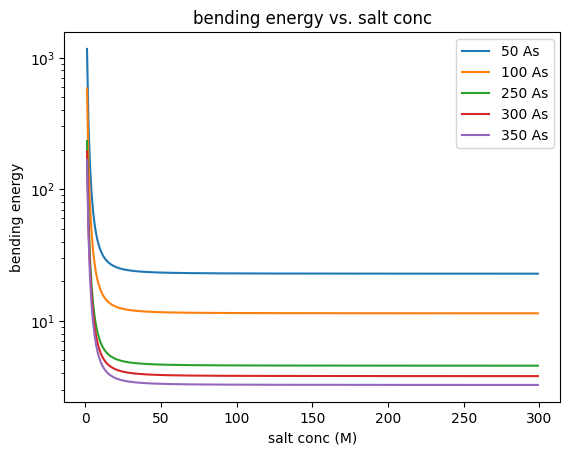

In [ ]:
##goal- plot bending energy as a function of [salt]
## do for a handful of tail lengths (50, 100, 250, 300, 350) as different lines.
#f(g(salt)) = bending energy
  #g(salt) = l_p
  #f(l_p) = bending energy

import matplotlib.pyplot as plt
import numpy as np

#constants
l_p_base = 8 #nm

salt_concs = np.arange(0,300)
numA = 50 #change
numA_list = [50, 100, 250, 300, 350]
d_A = 2.6 + 0.34/2 #nm. nt is ~2.6 nm, distance bw adjacent nt ~0.34 nm.

for n in numA_list:
  e_bend_values = []

  for s in salt_concs:
    A = 400
    B = 0.05
    l_p = l_p_base + (A/(s**2))
    k_b = l_p*4.1 #k_b is bending rigidity, 4.1 pN = kB*T
    r = (A*d_A)/2/np.pi
    e_bend = (2*(np.pi**2)*l_p)/(n*d_A*B)

    e_bend_values.append(e_bend)

  plt.plot(salt_concs, e_bend_values, label = str(n) + ' As')
  plt.xlabel('salt conc (M)')
  plt.ylabel('bending energy')
  plt.title('bending energy vs. salt conc')
  plt.legend()
  plt.yscale('log')

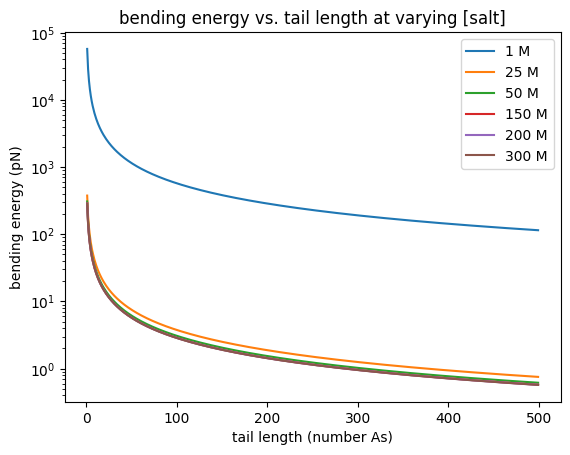

In [ ]:
##goal- plot bending energy as a function of tail length
## do for a handful of [salt]'s as different lines.
#f(g(salt)) = bending energy
  #g(salt) = l_p
  #f(l_p) = bending energy

import matplotlib.pyplot as plt
import numpy as np

#constants
l_p_base = 2 #nm

salt_concs = [1, 25, 50, 150, 200, 300]
numA = 50 #change
numA_list = np.arange(1,500)
d_A = 2.6 + 0.34/2 #nm. nt is ~2.6 nm, distance bw adjacent nt ~0.34 nm.

for s in salt_concs:
  e_bend_values = []

  for n in numA_list:
    A = 400
    B = 0.05
    l_p = l_p_base + (A/(s**2))
    k_b = l_p*4.1 #k_b is bending rigidity, 4.1 pN = kB*T
    r = (A*d_A)/2/np.pi
    e_bend = (2*(np.pi**2)*l_p)/(n*d_A*B)

    e_bend_values.append(e_bend)

  plt.plot(numA_list, e_bend_values, label = str(s) + ' M')
  plt.xlabel('tail length (number As)')
  plt.ylabel('bending energy (pN)')
  plt.title('bending energy vs. tail length at varying [salt]')
  plt.legend()
  plt.yscale('log')

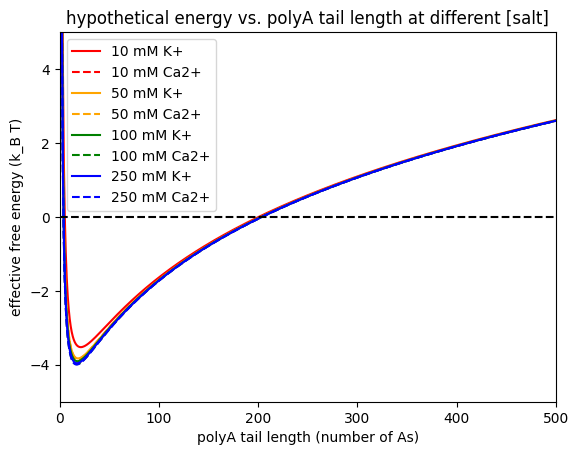

In [ ]:
#lay entropy+enthalpy for growing polyA (no pabp)

import numpy as np
import matplotlib.pyplot as plt

num_A = np.arange(1,600)
d_A = 2.6 + 0.34/2 #nm. nt is ~2.6 nm, distance bw adjacent nt ~0.34 nm.

def calc_E_tot(s, n, is_divalent=False):
  #E_bind
  E_bind = -8 #kB*T. starting payoff- enthalpy of PAP-mPSF binding (NOT validated).

  #E_bend
  l_p_base = 3 #nm. baseline l_p of ssRNA.
  if is_divalent:
    l_p = l_p_base + (20 / (s+10)**1.4) #l_p drops much more.
  else:
    l_p = l_p_base + (20 / (s+10))

  B = 0.5
  #E_bend = (2*(np.pi**2)*l_p)/((n*d_A)*B) #kB*T. decreases as l_p does.
  E_bend = (20*l_p)/(n*d_A)

  #S
  C = 0.34 #toggle
  S = -C * (np.log(n))**1.88 #entropy loss when forcing 2 ends to meet. S dominates at high values of n.
  return E_bind + E_bend - S

plt.plot(num_A, [calc_E_tot(10, n, False) for n in num_A],
         label='10 mM K+', color='red')
plt.plot(num_A, [calc_E_tot(10, n, True) for n in num_A],
         label = '10 mM Ca2+', color='red', linestyle='--')
plt.plot(num_A, [calc_E_tot(50, n, False) for n in num_A],
         label='50 mM K+', color='orange')
plt.plot(num_A, [calc_E_tot(50, n, True) for n in num_A],
         label = '50 mM Ca2+', color='orange', linestyle='--')
plt.plot(num_A, [calc_E_tot(100, n, False) for n in num_A],
         label='100 mM K+', color='green')
plt.plot(num_A, [calc_E_tot(100, n, True) for n in num_A],
         label = '100 mM Ca2+', color='green', linestyle='--')
plt.plot(num_A, [calc_E_tot(250, n, False) for n in num_A],
         label='250 mM K+', color='blue')
plt.plot(num_A, [calc_E_tot(250, n, True) for n in num_A],
         label = '250 mM Ca2+', color='blue', linestyle='--')
plt.hlines(y=0,xmin=0, xmax=600, color='black', linestyle='--')
plt.ylim(-5, 5)
plt.xlim(0,500)
plt.xlabel('polyA tail length (number of As)')
plt.ylabel('effective free energy (k_B T)')
plt.title('hypothetical energy vs. polyA tail length at different [salt]')
plt.legend()
